F1 Race Results Dataset:
       resultId  raceId  driverId  constructorId number  grid  position  \
0             1      18         1              1     22     1       1.0   
1             2      18         2              2      3     5       2.0   
2             3      18         3              3      7     7       3.0   
3             4      18         4              4      5    11       4.0   
4             5      18         5              1     23     3       5.0   
...         ...     ...       ...            ...    ...   ...       ...   
26754     26760    1144       825            210     20    14      16.0   
26755     26761    1144       859            215     30    12      17.0   
26756     26762    1144       822             15     77     9       NaN   
26757     26763    1144       861              3     43    20       NaN   
26758     26764    1144       815              9     11    10       NaN   

      positionText  positionOrder  points  laps         time milliseconds 

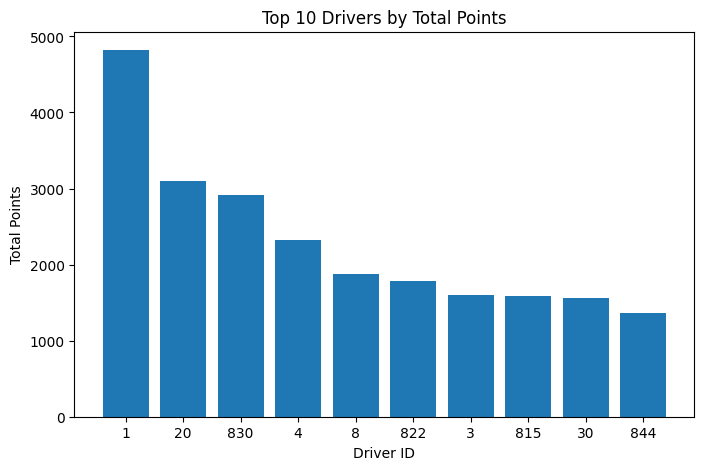

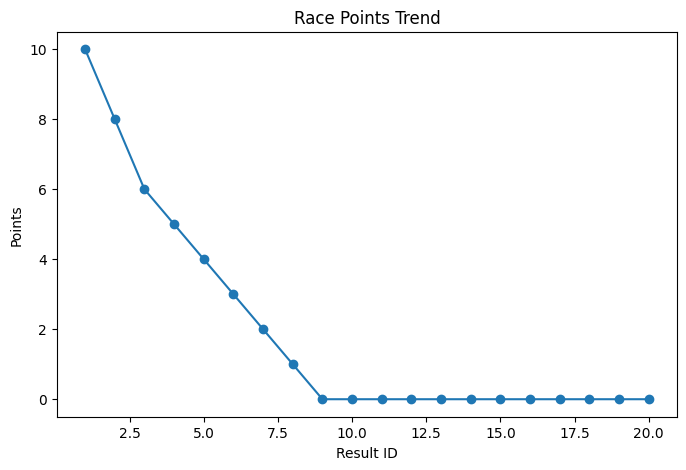

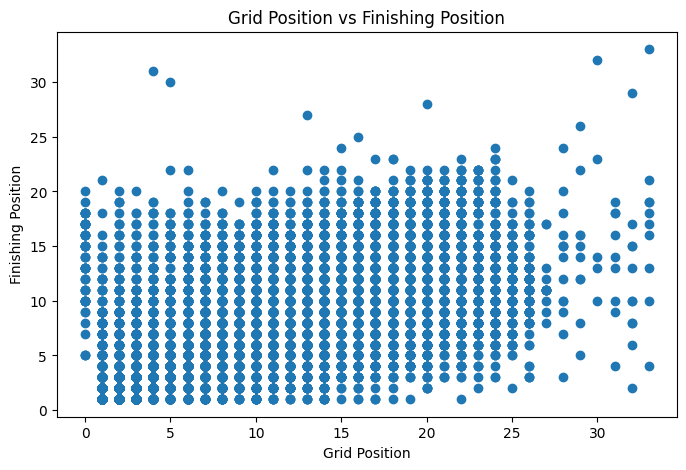

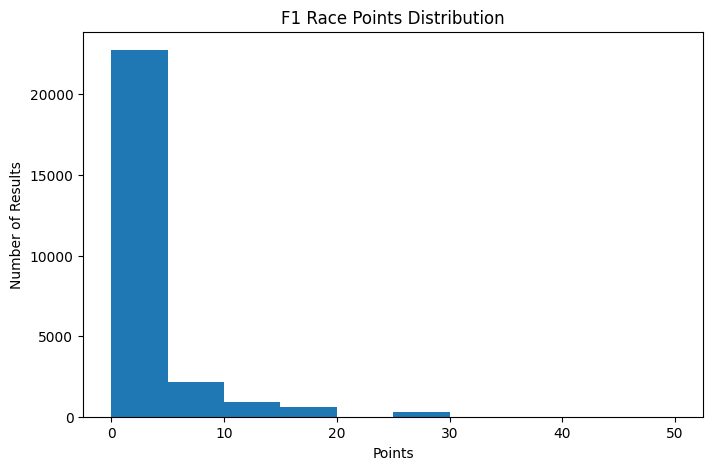

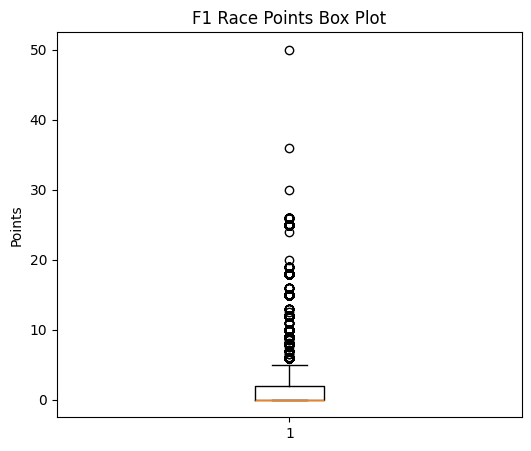

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv("results.csv")

# Convert important columns to numeric
numeric_columns = [
    "grid",
    "position",
    "points",
    "laps",
    "fastestLap",
    "rank",
    "fastestLapSpeed"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Display dataset
print("F1 Race Results Dataset:")
print(df)

# Display first five records
print("\nFirst Five Records:")
print(df.head())

# Display shape
print("\nDataset Shape:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Filter race results with points greater than 10
print("\nRace Results with Points Greater Than 10:")
print(df[df["points"] > 10])

# Filter drivers starting from top 10 grid positions
print("\nResults with Grid Position 10 or Better:")
print(df[df["grid"] <= 10])

# Sort by points
print("\nRace Results Sorted by Points:")
print(df.sort_values("points", ascending=False))

# Sort by finishing position
print("\nRace Results Sorted by Finishing Position:")
print(df.sort_values("position", ascending=True))

# Driver-wise total points
print("\nDriver-wise Total Points:")
print(df.groupby("driverId")["points"].sum())

# Driver-wise average finishing position
print("\nDriver-wise Average Finishing Position:")
print(df.groupby("driverId")["position"].mean())

# Calculate mean
print("\nMean Points:", df["points"].mean())

# Calculate median
print("Median Points:", df["points"].median())

# Calculate minimum
print("Minimum Points:", df["points"].min())

# Calculate maximum
print("Maximum Points:", df["points"].max())

# Calculate standard deviation
print("Standard Deviation:", df["points"].std())

# Correlation matrix
print("\nCorrelation Matrix:")
print(df[["grid", "position", "points", "laps"]].corr())

# Correlation between grid and finishing position
print(
    "\nCorrelation between Grid and Finishing Position:",
    df["grid"].corr(df["position"])
)

# Top 10 drivers by total points
top_drivers = (
    df.groupby("driverId")["points"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(top_drivers.index.astype(str), top_drivers.values)
plt.title("Top 10 Drivers by Total Points")
plt.xlabel("Driver ID")
plt.ylabel("Total Points")
plt.show()

# Line chart
plt.figure(figsize=(8, 5))
plt.plot(
    df.head(20)["resultId"],
    df.head(20)["points"],
    marker="o"
)
plt.title("Race Points Trend")
plt.xlabel("Result ID")
plt.ylabel("Points")
plt.show()

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df["grid"], df["position"])
plt.title("Grid Position vs Finishing Position")
plt.xlabel("Grid Position")
plt.ylabel("Finishing Position")
plt.show()

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df["points"], bins=10)
plt.title("F1 Race Points Distribution")
plt.xlabel("Points")
plt.ylabel("Number of Results")
plt.show()

# Box plot
plt.figure(figsize=(6, 5))
plt.boxplot(df["points"].dropna())
plt.title("F1 Race Points Box Plot")
plt.ylabel("Points")
plt.show()